In [1]:
import os
import os.path as osp
from scipy.io import loadmat
import cv2
from torch.utils.data import Dataset, DataLoader, Subset, random_split
from torchvision import transforms
from glob import glob
import numpy as np
from PIL import Image
import pandas as pd
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
from copy import deepcopy
import torch.optim as optim
from tqdm import tqdm
import time
import torchvision.transforms.functional as TF
import random
import math

In [2]:
aflw_img_num = 10000
image_size = 224
batch_size = 8
split = 0.8
lr = 5e-5
weight_decay = 3e-4
num_epochs = 10

In [3]:
image_root = '/home/cse/Desktop/Miju_work/Self_Supervised_Learning_with_ViT/AFLW'
style = "aflw-Original"          
annotation_root = os.path.join(image_root, 'annotation')

mat_path = osp.join('/home/cse/Desktop/Miju_work/SSL_With_ViT', 'AFLWinfo_release.mat')
aflwinfo = dict()
mat = loadmat(mat_path)
total_image = 24386
ra = np.squeeze(mat['ra']-1).tolist()
aflwinfo['train-index'] = ra[:20000]
aflwinfo['test-index'] = ra[20000:]
aflwinfo['name-list'] = []

name_list = [str(name[0]) for name in mat['nameList']]
aflw_train_images_name = [name_list[i] for i in aflwinfo['train-index']]
aflw_test_images_name = [name_list[i] for i in aflwinfo['test-index']]

aflw_train_images_name = [eval(name)[0] if isinstance(name, str) and name.startswith("[") else name for name in aflw_train_images_name]
aflw_test_images_name = [eval(name)[0] if isinstance(name, str) and name.startswith("[") else name for name in aflw_test_images_name]

aflw_train_images = [osp.join(image_root, style, name) for name in aflw_train_images_name]
aflw_test_images = [osp.join(image_root, style, name) for name in aflw_test_images_name]

all_images = aflw_train_images
images = all_images[:aflw_img_num]

In [4]:
valid_images = []
for idx in range(len(mat['nameList'])):
    image_name = mat['nameList'][idx][0][0]
    img_path = os.path.join(image_root, style, image_name)
    
    if os.path.exists(img_path):
        image = cv2.imread(img_path)
        if image is not None:
            valid_images.append(idx)

print(f"Filtered valid images: {len(valid_images)} / {len(mat['nameList'])}")

Filtered valid images: 24340 / 24386


In [5]:
import os
import os.path as osp
import cv2
from scipy.io import loadmat

# Base paths
image_root = '/home/cse/Desktop/Miju_work/Self_Supervised_Learning_with_ViT/AFLW'
style = "aflw-Original"
annotation_root = os.path.join(image_root, 'annotation')
mat_path = osp.join('/home/cse/Desktop/Miju_work/SSL_With_ViT', 'AFLWinfo_release.mat')

# Load .mat
mat = loadmat(mat_path)
total_image = 24386

# Prepare indices
ra = np.squeeze(mat['ra'] - 1).tolist()
aflwinfo = {
    'train-index': ra[:20000],
    'test-index': ra[20000:],
    'name-list': [],
}

# Extract and fix image names
name_list = [str(name[0]) for name in mat['nameList']]

# Get names for train and test
aflw_train_images_name = [name_list[i] for i in aflwinfo['train-index']]
aflw_test_images_name = [name_list[i] for i in aflwinfo['test-index']]

# Convert strings like "[‘image123.png’]" to "image123.png"
def fix_name(name):
    return eval(name)[0] if isinstance(name, str) and name.startswith("[") else name

aflw_train_images_name = [fix_name(name) for name in aflw_train_images_name]
aflw_test_images_name = [fix_name(name) for name in aflw_test_images_name]

# === FILTER VALID IMAGES ONLY ===

def is_valid_image(img_path):
    if os.path.exists(img_path):
        img = cv2.imread(img_path)
        if img is not None:
            return True
    return False

# Filter train and test images
aflw_train_images = [
    osp.join(image_root, style, name)
    for name in aflw_train_images_name
    if is_valid_image(osp.join(image_root, style, name))
]

aflw_test_images = [
    osp.join(image_root, style, name)
    for name in aflw_test_images_name
    if is_valid_image(osp.join(image_root, style, name))
]

# Final selections
all_images = aflw_train_images
images = all_images[:aflw_img_num]

# Optional print
print(f"Filtered train images: {len(aflw_train_images)} / {len(aflwinfo['train-index'])}")
print(f"Filtered test images:  {len(aflw_test_images)} / {len(aflwinfo['test-index'])}")
print(f"Using first {len(images)} images from filtered training set.")


Filtered train images: 19962 / 20000
Filtered test images:  4378 / 4386
Using first 10000 images from filtered training set.


In [298]:
k = 246

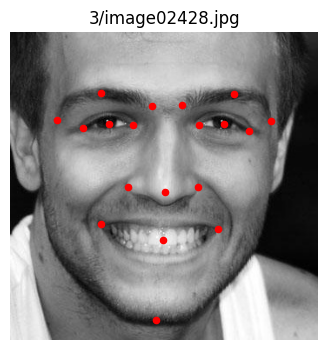

In [299]:
name = mat['nameList'][k][0][0]
data = mat['data'][k]
landmarks = np.array([[data[j], data[j+19]] for j in range(19)])

image = cv2.imread(os.path.join(image_root, style, name))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
h, w = image.shape[:2]
bbox = mat['bbox'][k]
x1, x2, y1, y2 = bbox
x1, x2 = int(min(x1, x2)), int(max(x1, x2))
y1, y2 = int(min(y1, y2)), int(max(y1, y2))
x1, y1 = max(0, x1), max(0, y1)
x2, y2 = min(w - 1, x2), min(h - 1, y2)

landmarks = landmarks - np.array([x1, y1])

plt.figure(figsize=(4,4))
plt.imshow(image)
plt.scatter(landmarks[:,0], landmarks[:,1], s=20, c='red')
plt.title(name)
plt.axis('off')
plt.show()

In [300]:
class RandomRotate:
    def __init__(self, degrees):
        self.degrees = degrees

    def __call__(self, image, landmarks):
        angle = random.uniform(-self.degrees, self.degrees)
        w, h = image.size

        image = TF.rotate(image, angle)

        landmarks = landmarks.clone()
        landmarks[:, 0] *= w
        landmarks[:, 1] *= h

        cx, cy = w / 2, h / 2
        theta = math.radians(angle)

        rot_matrix = np.array([
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta),  math.cos(theta)]
        ])

        landmarks = landmarks.numpy()
        landmarks -= [cx, cy]
        landmarks = np.dot(landmarks, rot_matrix.T)
        landmarks += [cx, cy]

        landmarks = np.clip(landmarks, 0, [w, h])
        landmarks[:, 0] /= w
        landmarks[:, 1] /= h

        return image, torch.tensor(landmarks, dtype=torch.float32)


In [301]:
train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomApply([
        transforms.ColorJitter(
            brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05
        )
    ], p=0.4),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])
test_transform = transforms.Compose([
    # transforms.ToPILImage(),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])


class AFLWDataset(Dataset):
    def __init__(self, images, annotation_root, transform=None):
        self.images = images
        self.samples = []
        self.transform = transform
        self.annotation_root = annotation_root

    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        image_name = mat['nameList'][idx][0][0]
        img_path = os.path.join(image_root, style, image_name)
        annotation = mat['data'][idx]
        default_landmarks = np.array([[annotation[j], annotation[j+19]] for j in range(19)])
        

        bbox = mat['bbox'][idx]
        x1, x2, y1, y2 = bbox
        x1, x2 = int(min(x1, x2)), int(max(x1, x2))
        y1, y2 = int(min(y1, y2)), int(max(y1, y2))
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(w - 1, x2), min(h - 1, y2)

        landmarks = default_landmarks - np.array([x1, y1])
        # print(f"image_name : {image_name}, image_path : {img_path}, landmarks : {landmarks}\n")
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h_orig, w_orig = image.shape[:2]

        image = cv2.resize(image, (image_size, image_size))
        landmarks[:, 0] *= (image_size / w_orig)
        landmarks[:, 1] *= (image_size / h_orig)
        landmarks[:, 0] /= image_size
        landmarks[:, 1] /= image_size

        image = Image.fromarray(image)

        if self.transform:
            if isinstance(self.transform, tuple):
                image, landmarks = self.transform[0](image, landmarks)
                image = self.transform[1](image)
            else:
                image = self.transform(image)

        landmarks = torch.tensor(landmarks, dtype=torch.float32)

        return image, landmarks.reshape(-1), image_name, landmarks



from sklearn.model_selection import train_test_split
train_images, val_images =  train_test_split(images, train_size=split, random_state=42)
train_dataset = AFLWDataset(images=train_images, annotation_root=annotation_root, transform=train_transform)
test_dataset = AFLWDataset(images=val_images, annotation_root=annotation_root, transform=test_transform)


train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=os.cpu_count())
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=os.cpu_count())
print(f"Dataset : AFLW-Style | Total samples: {len(all_images)} | Selected images : {len(images)} | Train dataset : {len(train_dataset)} | Test dataset : {len(test_dataset)} | lr : {lr} | batch_size : {batch_size} | num_epoch : {num_epochs} | weight_decay : {weight_decay}")


Dataset : AFLW-Style | Total samples: 20000 | Selected images : 10000 | Train dataset : 8000 | Test dataset : 2000 | lr : 5e-05 | batch_size : 8 | num_epoch : 10 | weight_decay : 0.0003


In [302]:
for img, landmarks, fname, anno in train_loader:
    break

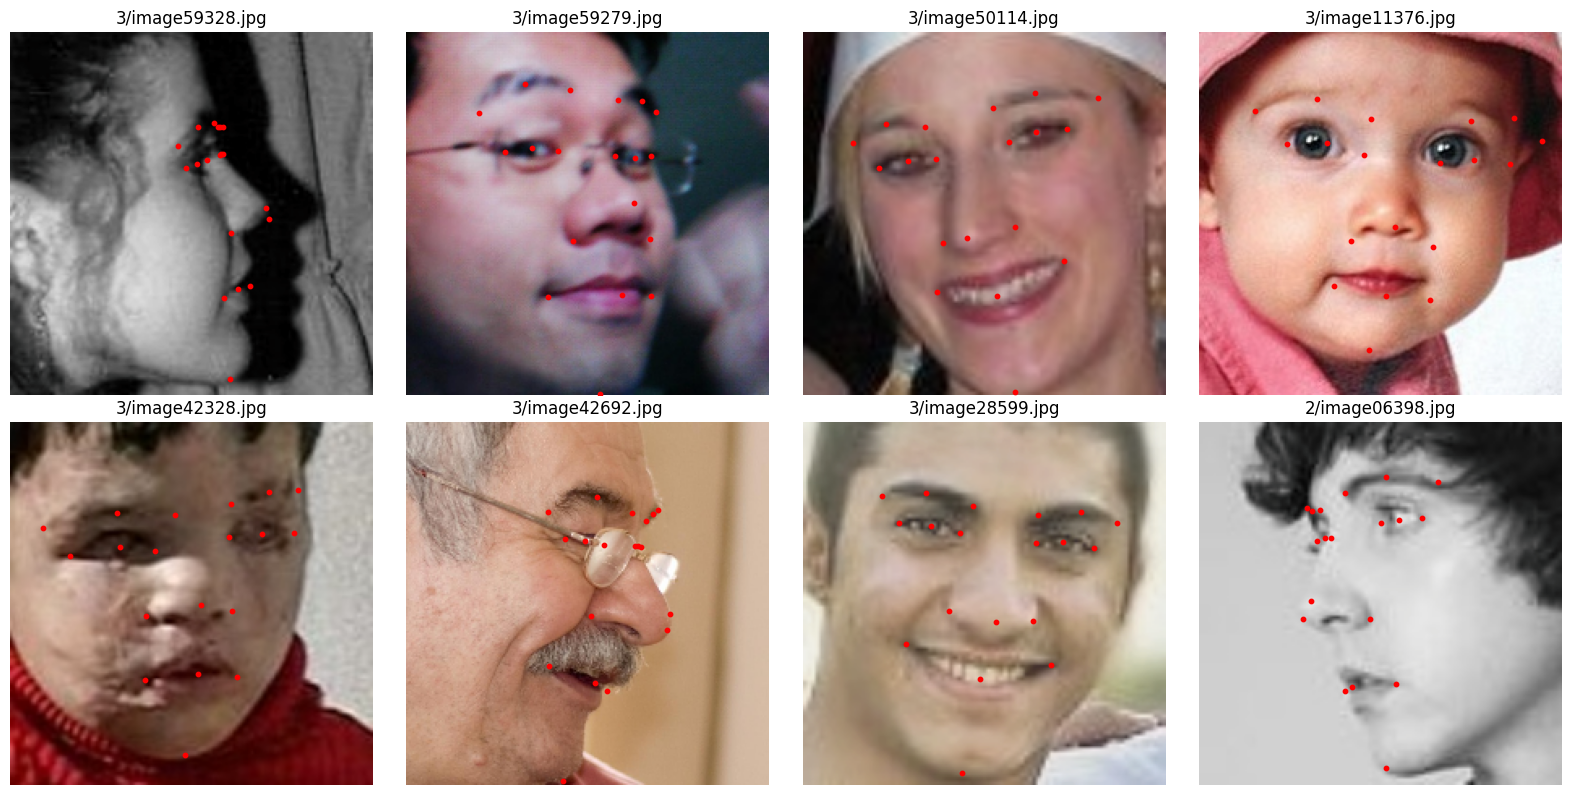

In [303]:
import matplotlib.pyplot as plt
import torch

def unnormalize_image(image_tensor):
    """Undo normalization on a torch tensor image."""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return image_tensor * std + mean

def plot_batch_with_landmarks(images, landmarks, titles=None, max_plot=8):
    """
    Plot a batch of images with landmarks using subplots.
    Args:
        images: Tensor of shape (B, 3, H, W)
        landmarks: Tensor of shape (B, 38)
        titles: Optional list of titles (e.g., image names)
        max_plot: Max number of images to show
    """
    B = min(images.size(0), max_plot)
    cols = 4
    rows = (B + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = axes.flatten()

    for i in range(B):
        img = unnormalize_image(images[i]).permute(1, 2, 0).cpu().numpy()
        img = (img * 255).clip(0, 255).astype("uint8")

        lm = landmarks[i].reshape(-1, 2).cpu().numpy()
        lm *= image_size  # convert from normalized [0–1] to pixels

        ax = axes[i]
        ax.imshow(img)
        ax.scatter(lm[:, 0], lm[:, 1], c='red', s=10)
        if titles is not None:
            ax.set_title(titles[i])
        ax.axis("off")

    # Hide remaining axes if batch < subplot size
    for j in range(B, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()
# Get a batch from train_loader
images, landmarks, names, _ = next(iter(train_loader))

# Plot batch
plot_batch_with_landmarks(images, landmarks, titles=names, max_plot=8)


<h1>NME and AUC</h1>

In [ ]:
def calculate_nme(preds, targets, normalize='bbox'):
    B, N, _ = preds.shape
    error = torch.norm(preds - targets, dim=2)  # (B, N)
    nme = torch.zeros(B, device=preds.device)

    for i in range(B):
        if normalize == 'bbox':
            min_x, _ = torch.min(targets[i, :, 0], 0)
            max_x, _ = torch.max(targets[i, :, 0], 0)
            min_y, _ = torch.min(targets[i, :, 1], 0)
            max_y, _ = torch.max(targets[i, :, 1], 0)
            norm_factor = torch.sqrt((max_x - min_x)**2 + (max_y - min_y)**2)
        else:
            norm_factor = 1.0
        nme[i] = torch.mean(error[i]) / (norm_factor + 1e-6)
    return nme

def compute_auc(errors, failure_threshold=0.8, step=0.0001):
    errors = np.array(errors)
    x = np.arange(0, failure_threshold + step, step)
    ced = [(errors < xi).sum() / len(errors) for xi in x]
    auc = np.trapz(ced, x) / failure_threshold
    return auc, x, ced

In [ ]:
def train_landmark_model(model, train_loader, val_loader, criterion, optimizer, epochs=50, save_path='Result_SSL/best_landmark_model_aflw_2.pt'):
    best_val_loss = float('inf')
    start_time = time.time()

    all_nmes = []
    all_aucs = []

    for epoch in range(epochs):
        epoch_start = time.time()

        # Training
        model.train()
        train_loss = 0.0
        for images, landmarks, *_ in train_loader:
            images, landmarks = images.cuda(), landmarks.cuda()
            landmarks = landmarks.view(images.size(0), -1, 2)

            preds = model(images)
            loss = criterion(preds, landmarks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        nme_list = []

        with torch.no_grad():
            for images, landmarks, *_ in val_loader:
                images, landmarks = images.cuda(), landmarks.cuda()
                landmarks = landmarks.view(images.size(0), -1, 2)

                preds = model(images)
                loss = criterion(preds, landmarks)
                val_loss += loss.item()

                nme_batch = calculate_nme(preds, landmarks)
                nme_list.extend(nme_batch.cpu().numpy())

        avg_val_loss = val_loss / len(val_loader)
        final_nme = np.mean(nme_list)
        auc_score, _, _ = compute_auc(nme_list)

        all_nmes.append(final_nme)
        all_aucs.append(auc_score)

        epoch_end = time.time()
        epoch_duration = (epoch_end - epoch_start) / 60.0
        elapsed = (epoch_end - start_time) / 60.0
        est_time_left = (epochs - (epoch + 1)) * epoch_duration

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | "
              f"NME: {final_nme:.4f} | AUC@0.8: {auc_score:.4f} | "
              f"Time: {epoch_duration:.2f}m | Elapsed: {elapsed:.2f}m | ETA: {est_time_left:.2f}m")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': best_val_loss,
            }, save_path)
            print(f"Saved best model with val loss: {best_val_loss:.4f}")


        
    print(f"\nFinal Mean NME over all epochs: {np.mean(all_nmes):.4f}")
    print(f"Final Mean AUC@0.8 over all epochs: {np.mean(all_aucs):.4f}")
    print(f"Best NME: {np.min(all_nmes):.4f}")
    print(f"Best AUC@0.8: {np.max(all_aucs):.4f}")


        
    return all_nmes, all_aucs



In [ ]:
nme_list, auc_list = train_landmark_model(
    model, train_loader, test_loader, criterion, optimizer, epochs=num_epochs
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(nme_list)+1), nme_list, marker='o', label='NME', color='blue')
plt.xlabel("Epoch")
plt.ylabel("NME")
plt.title("NME over Epochs")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(auc_list)+1), auc_list, marker='s', label='AUC@0.1', color='green')
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("AUC over Epochs")
plt.grid(True)

plt.tight_layout()
plt.show()